# Neural Receiver for OFDM SIMO Systems

## GPU Configuration and Imports <a class="anchor" id="GPU-Configuration-and-Imports"></a>

In [1]:
import os
import tensorflow as tf
import sys
import gc
print(sys.version)
print(sys.executable)
print(sys.version_info)

os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"]="0" # 0,1,2,3
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"

# Configure the notebook to use only a single GPU and allocate only as much memory as needed
# For more details, see https://www.tensorflow.org/guide/gpu
gpus = tf.config.list_physical_devices('GPU')

print(gpus)

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print("Error loading GPU:", e)
# Avoid warnings from TensorFlow
tf.get_logger().setLevel('ERROR')

2026-02-18 13:24:48.624717: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-18 13:24:49.067454: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-18 13:24:49.067548: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-18 13:24:49.120997: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-18 13:24:49.250517: I tensorflow/core/platform/cpu_feature_guar

3.10.12 (main, Jan 26 2026, 14:55:28) [GCC 11.4.0]
/usr/bin/python3
sys.version_info(major=3, minor=10, micro=12, releaselevel='final', serial=0)
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2026-02-18 13:24:52.419697: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:55:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-02-18 13:24:52.814570: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:55:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-02-18 13:24:52.814616: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:55:00.0/numa_node
Your kernel may have been built without NUMA support.


In [2]:
# Import Sionna
try:
    import sionna
except ImportError as e:
    # Install Sionna if package is not already installed
    import os
    os.system("pip install sionna")
    import sionna

sionna.phy.config.seed = 42 # Set seed for reproducible random number generation

2026-02-18 13:24:53.566424: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:55:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-02-18 13:24:53.566508: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:55:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-02-18 13:24:53.566528: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:55:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-02-18 13:24:53.876479: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:55:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-02-18 13:24:53.876531: I external/local_xla/xla/stream_executor

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pickle

from tensorflow.keras import Model
from tensorflow.keras.layers import Layer, Conv2D, LayerNormalization, Dense, ReLU, Reshape, Conv2DTranspose, LeakyReLU, Flatten, AveragePooling2D
from tensorflow.nn import relu
from tensorflow.keras.models import Sequential

from sionna.phy.channel.tr38901 import Antenna, AntennaArray, CDL
from sionna.phy.channel import OFDMChannel, RayleighBlockFading, GenerateOFDMChannel
from sionna.phy.mimo import StreamManagement
from sionna.phy.ofdm import ResourceGrid, ResourceGridMapper, LSChannelEstimator, LMMSEEqualizer, LinearInterpolator, RemoveNulledSubcarriers, ResourceGridDemapper, LMMSEInterpolator, BaseChannelEstimator, BaseChannelInterpolator
from sionna.phy.utils import ebnodb2no, insert_dims, flatten_last_dims, log10, expand_to_rank, split_dim
from sionna.phy.fec.ldpc.encoding import LDPC5GEncoder
from sionna.phy.fec.ldpc.decoding import LDPC5GDecoder
from sionna.phy.mapping import BinarySource, Mapper, Demapper, Constellation
from sionna.phy.utils.metrics import compute_ber
from sionna.phy.utils import sim_ber, hard_decisions

from tqdm.auto import tqdm

## Simulation Parameters <a class="anchor" id="Simulation-Parameters"></a>

In [4]:
# ## Channel configuration
carrier_frequency = 3.5e9 # Hz
cdl_model = "C" # CDL model to use
delay_spread = 100e-9 # s
speed = 10.0 # Speed for evaluation and training [m/s]
# Ultra-high coherence channel
# delay_spread = 10e-9  # 10 ns → Bc ≈ 16 MHz
# speed = 0.1  # 0.1 m/s → Tc ≈ 428 ms

# SNR range for evaluation and training [dB]
ebno_db_min = 0.0
ebno_db_max = 15.0

############################################
## OFDM waveform configuration
subcarrier_spacing = 30e3 # Hz
fft_size = 128 # Number of subcarriers forming the resource grid, including the null-subcarrier and the guard bands
num_ofdm_symbols = 14 # Number of OFDM symbols forming the resource grid
dc_null = True # Null the DC subcarrier
num_guard_carriers = [5, 6] # Number of guard carriers on each side
pilot_pattern = "kronecker" # Pilot pattern
pilot_ofdm_symbol_indices = [2, 11] # Index of OFDM symbols carrying pilots
cyclic_prefix_length = 0 # Simulation in frequency domain. This is useless

############################################
## Modulation and coding configuration
num_bits_per_symbol = 6 # 64-QAM
coderate = 0.5 # 0.5 # Coderate for LDPC code
noise_dim = 100

############################################
## Neural receiver configuration
num_conv_channels = 128 # Number of convolutional channels for the convolutional layers forming the neural receiver
GAN_DIM=64

############################################
## Training configuration
num_training_iterations = 30000 # Number of training iterations
batch_size = 128 # Training batch size
training_batch_size = 32

############################################
## Evaluation configuration
results_filename = "neural_receiver_results" # Location to save the results

The `StreamManagement` class is used to configure the receiver-transmitter association and the number of streams per transmitter.
A SIMO system is considered, with a single transmitter equipped with a single non-polarized antenna.
Therefore, there is only a single stream, and the receiver-transmitter association matrix is $[1]$.
The receiver is equipped with an antenna array.

In [5]:
stream_manager = StreamManagement(np.array([[1]]), # Receiver-transmitter association matrix
                                  1)               # One stream per transmitter

The `ResourceGrid` class is used to configure the OFDM resource grid. It is initialized with the parameters defined above.

In [6]:
resource_grid = ResourceGrid(num_ofdm_symbols = num_ofdm_symbols,
                             fft_size = fft_size,
                             subcarrier_spacing = subcarrier_spacing,
                             num_tx = 1,
                             num_streams_per_tx = 1,
                             cyclic_prefix_length = cyclic_prefix_length,
                             dc_null = dc_null,
                             pilot_pattern = pilot_pattern,
                             pilot_ofdm_symbol_indices = pilot_ofdm_symbol_indices,
                             num_guard_carriers = num_guard_carriers)

2026-02-18 13:24:54.567516: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


Outer coding is performed such that all the databits carried by the resource grid with size `fft_size`x`num_ofdm_symbols` form a single codeword.

In [7]:
# Codeword length. It is calculated from the total number of databits carried by the resource grid, and the number of bits transmitted per resource element
n = int(resource_grid.num_data_symbols*num_bits_per_symbol)
# Number of information bits per codeword
k = int(n*coderate)

The SIMO link is setup by considering an uplink transmission with one user terminal (UT) equipped with a single non-polarized antenna, and a base station (BS) equipped with an antenna array.
One can try other configurations for the BS antenna array.

In [8]:
ut_antenna = Antenna(polarization="single",
                     polarization_type="V",
                     antenna_pattern="38.901",
                     carrier_frequency=carrier_frequency)

# bs_array = AntennaArray(num_rows=1,
#                         num_cols=1,
#                         polarization="dual",
#                         polarization_type="VH",
#                         antenna_pattern="38.901",
#                         carrier_frequency=carrier_frequency)

bs_array = AntennaArray(num_rows=1,
                        num_cols=1,
                        polarization="single", # dual
                        polarization_type="V", # VH
                        antenna_pattern="38.901",
                        carrier_frequency=carrier_frequency)

## Neural Receiver <a class="anchor" id="Neural-Receiver"></a>

The next cell defines the Keras layers that implement the neural receiver.
As in [1] and [2], a neural receiver using residual convolutional layers is implemented. Convolutional layers are leveraged to efficienly process the 2D resource grid, that is fed as an input to the neural receiver.
Residual (skip) connections are used to avoid gradient vanishing [3].

For convinience, a Keras layer that implements a *residual block* is first defined. The Keras layer that implements the neural receiver is built by stacking such blocks. The following figure shows the architecture of the neural receiver.

In [9]:
class ResidualBlock(Layer):
    r"""
    This Keras layer implements a convolutional residual block made of two convolutional layers with ReLU activation, layer normalization, and a skip connection.
    The number of convolutional channels of the input must match the number of kernel of the convolutional layers ``num_conv_channel`` for the skip connection to work.

    Input
    ------
    : [batch size, num time samples, num subcarriers, num_conv_channel], tf.float
        Input of the layer

    Output
    -------
    : [batch size, num time samples, num subcarriers, num_conv_channel], tf.float
        Output of the layer
    """
    def __init__(self, kernel_size=[3,3], **kwargs):
        super().__init__(**kwargs)
        self._kernel_size = kernel_size

    def build(self, input_shape):

        # Layer normalization is done over the last three dimensions: time, frequency, conv 'channels'
        self._layer_norm_1 = LayerNormalization(axis=(-1, -2, -3))
        self._conv_1 = Conv2D(filters=num_conv_channels,
                              kernel_size=self._kernel_size,
                              padding='same',
                              activation=None)
        # Layer normalization is done over the last three dimensions: time, frequency, conv 'channels'
        self._layer_norm_2 = LayerNormalization(axis=(-1, -2, -3))
        self._conv_2 = Conv2D(filters=num_conv_channels,
                              kernel_size=self._kernel_size,
                              padding='same',
                              activation=None)

    def call(self, inputs):
        z = self._layer_norm_1(inputs)
        z = relu(z)
        z = self._conv_1(z)
        z = self._layer_norm_2(z)
        z = relu(z)
        z = self._conv_2(z) # [batch size, num time samples, num subcarriers, num_channels]
        # Skip connection
        z = z + inputs

        return z

class NeuralReceiver(Layer):
    r"""
    Keras layer implementing a residual convolutional neural receiver.

    This neural receiver is fed with the post-DFT received samples, forming a resource grid of size num_of_symbols x fft_size, and computes LLRs on the transmitted coded bits.
    These LLRs can then be fed to an outer decoder to reconstruct the information bits.

    As the neural receiver is fed with the entire resource grid, including the guard bands and pilots, it also computes LLRs for these resource elements.
    They must be discarded to only keep the LLRs corresponding to the data-carrying resource elements.

    Input
    ------
    y : [batch size, num rx antenna, num ofdm symbols, num subcarriers], tf.complex
        Received post-DFT samples.

    no : [batch size], tf.float32
        Noise variance. At training, a different noise variance value is sampled for each batch example.

    Output
    -------
    : [batch size, num ofdm symbols, num subcarriers, num_bits_per_symbol]
        LLRs on the transmitted bits.
        LLRs computed for resource elements not carrying data (pilots, guard bands...) must be discarded.
    """

    def build(self, input_shape):

        # Input convolution
        self._input_conv = Conv2D(filters=num_conv_channels,
                                  kernel_size=[3,3],
                                  padding='same',
                                  activation=None)
        # Residual blocks
        self._res_block_1 = ResidualBlock()
        self._res_block_2 = ResidualBlock()
        self._res_block_3 = ResidualBlock()
        self._res_block_4 = ResidualBlock()
        # Output conv
        self._output_conv = Conv2D(filters=num_bits_per_symbol,
                                   kernel_size=[3,3],
                                   padding='same',
                                   activation=None)

    def call(self, y, no):

        # Feeding the noise power in log10 scale helps with the performance
        no = log10(no)

        # Stacking the real and imaginary components of the different antennas along the 'channel' dimension
        y = tf.transpose(y, [0, 2, 3, 1]) # Putting antenna dimension last
        no = insert_dims(no, 3, 1)
        no = tf.tile(no, [1, y.shape[1], y.shape[2], 1])
        # z : [batch size, num ofdm symbols, num subcarriers, 2*num rx antenna + 1]
        z = tf.concat([tf.math.real(y),
                       tf.math.imag(y),
                       no], axis=-1)
        # Input conv
        z = self._input_conv(z)
        # Residual blocks
        z = self._res_block_1(z)
        z = self._res_block_2(z)
        z = self._res_block_3(z)
        z = self._res_block_4(z)
        # Output conv
        z = self._output_conv(z)

        return z

## End-to-end System <a class="anchor" id="End-to-end-System"></a>

### Frame Conv2D

In [ ]:
class ConstellationGenerator(Layer):
    """generate constellation residuals"""
    def __init__(self, num_bits_per_symbol=num_bits_per_symbol, 
                 num_ofdm_symbols=14, 
                 fft_size=128,
                 filters=[64, 128, 256],
                 **kwargs):
        super().__init__(**kwargs)
        self.num_bits_per_symbol = num_bits_per_symbol
        self.num_constellation_points = 2 ** num_bits_per_symbol
        self.num_ofdm_symbols = num_ofdm_symbols
        self.fft_size = fft_size
        self.filters = filters
        
        # Conv2D feature extraction (same as GAN structure)
        self.conv_layers = []
        for i, num_filters in enumerate(filters):
            self.conv_layers.append(Conv2D(
                filters=num_filters, 
                kernel_size=(3, 3), 
                padding='same', 
                use_bias=False,
                name=f'conv2D_{i}'
            ))
            self.conv_layers.append(ReLU(name=f'relu_{i}'))
        
        # Pooling (NOTE)
        self.adaptive_pool = AveragePooling2D(pool_size=(2, 4))  # [14, 128] -> [7, 32]
        self.flatten = Flatten()

        # SNR embedding (scalar SNR to feature vector)
        # self.snr_dense1 = Dense(64, activation='relu', name='snr_embedding1')
        self.dense = Dense(256, activation='relu', name='dense1')

        self.constellation_I_dense = Dense(self.num_constellation_points)
        self.constellation_Q_dense = Dense(self.num_constellation_points)
        
    def build(self, input_shape):
        super().build(input_shape)
    
    def call(self, bit_grid, ebno_db, training=False):
        """
        Args:
            bit_grid: [batch, tx, rx, num_ofdm_symbols, fft_size]
            ebno_db: scalar - SNR in dB
        Returns:
            points_I: [batch, M]
            points_Q: [batch, M]
        """
        batch_size = tf.shape(bit_grid)[0]
        x = tf.cast(bit_grid, dtype=tf.float32)  # [batch, 14, 128, 6]
        
        # Conv2D feature extraction
        for layer in self.conv_layers:
            x = layer(x, training=training)

        # adaptive pooling reduces spatial dimensions gradually (NOTE)
        x = self.adaptive_pool(x)  # [batch, 7, 32, 256]
        x = self.flatten(x)  # [batch, 7*32*256]

        # Process SNR through embedding network
        ebno_db_expanded = tf.reshape(ebno_db, [batch_size, 1])
        # snr_ft = self.snr_dense1(ebno_db_expanded, training=training)
        # concat bit grid with SNR
        x = tf.concat([x, ebno_db_expanded], axis=-1)  # [batch, 7*32*256 + 1]
        
        x = self.dense(x)

        # generate constellation
        points_I = self.constellation_I_dense(x, training=training)  # [batch, M]
        points_Q = self.constellation_Q_dense(x, training=training)  # [batch, M]

        # per-symbol normalization
        point_energy = points_I**2 + points_Q**2  # [batch, M]
        avg_energy = tf.reduce_mean(point_energy, axis=-1, keepdims=True)  # [batch, 1]
        normalization_factor = tf.sqrt(avg_energy)
        points_I = points_I / normalization_factor
        points_Q = points_Q / normalization_factor
        
        return points_I, points_Q


class ConditionalMapper(Layer):
    """
    map each sample in batch separately.
    """
    def __init__(self, num_bits_per_symbol=num_bits_per_symbol, 
                 num_ofdm_symbols=14,
                 fft_size=128,
                 filters=[64, 128, 256],
                 resource_grid=None,
                 return_indices=False, 
                 **kwargs):
        super().__init__(**kwargs)
        self.num_bits_per_symbol = num_bits_per_symbol
        self.return_indices = return_indices
        self._resource_grid = resource_grid
        
        if resource_grid is not None:
            self._rg_type = self._resource_grid.build_type_grid()  # [1, 1, ofdm, fft]
            self._rg_type = tf.squeeze(self._rg_type, axis=[0, 1])  # [ofdm, fft]
            self._data_ind = tf.where(self._rg_type == 0)  # [num_data_positions, 2]
            self._num_data_positions = tf.shape(self._data_ind)[0]

        # build constellation generator
        self.constellation_generator = ConstellationGenerator(
            num_bits_per_symbol,
            num_ofdm_symbols=num_ofdm_symbols,
            fft_size=fft_size,
            filters=filters
        )
        
        # Pre-compute bit positions for mapping
        n = num_bits_per_symbol
        self._bit_positions = tf.cast(tf.range(n-1, -1, -1), dtype=tf.int32)
    
    def _reshape_bits_to_grid(self, bits):
        """
        bit grid, pilots/guard bands/dc 0
        """
        batch_size = tf.shape(bits)[0]
        bit_grid = tf.zeros([batch_size, 14, 128, self.num_bits_per_symbol], dtype=bits.dtype)
        
        if self._resource_grid is not None:
            num_data_symbols = self._num_data_positions
            expected_bits = num_data_symbols * self.num_bits_per_symbol
            
            bits_for_data = bits[:, :expected_bits]
            bits_reshaped = tf.reshape(bits_for_data, 
                                      [batch_size, num_data_symbols, self.num_bits_per_symbol])
            
            batch_indices = tf.repeat(tf.range(batch_size, dtype=tf.int64), num_data_symbols)
            batch_indices = tf.reshape(batch_indices, [-1, 1])
            data_ind_tiled = tf.tile(self._data_ind, [batch_size, 1])
            scatter_indices = tf.concat([batch_indices, data_ind_tiled], axis=1)
            bits_flat = tf.reshape(bits_reshaped, [-1, self.num_bits_per_symbol])
            
            bit_grid = tf.tensor_scatter_nd_update(bit_grid, scatter_indices, bits_flat)
        else:
            bit_grid = tf.reshape(bits, [batch_size, 14, 128, self.num_bits_per_symbol])
        
        return bit_grid

    def _map_bits_to_symbols(self, bits, points_I, points_Q):
        """
        Args:
            bits: [batch, num_bits] - binary values
            constellation_points: [batch, 2^num_bits_per_symbol] - complex constellation
        Returns:
            x_real: [batch, num_symbols, 2] where last dim is [I, Q]
            indices: [batch, num_symbols] - symbol indices
        """
        # Convert to int32
        bits = tf.cast(bits, dtype=tf.int32)
        
        # [batch, num_bits] -> [batch, num_symbols, num_bits_per_symbol]
        n1 = int(bits.shape[-1] / self.num_bits_per_symbol)
        new_shape = [n1, self.num_bits_per_symbol]
        bits = split_dim(bits, new_shape, axis=tf.rank(bits)-1)
        
        # Convert bits to integer indices
        shifted_bits = tf.bitwise.left_shift(bits, self._bit_positions)
        int_rep = tf.reduce_sum(shifted_bits, axis=-1)  # [batch, num_symbols]
        
        # batch_dims=1 locks batch so each sample indices only access that sample's points 
        x_I = tf.gather(points_I, int_rep, batch_dims=1, axis=1)  # [batch, num_symbols]
        x_Q = tf.gather(points_Q, int_rep, batch_dims=1, axis=1)  # [batch, num_symbols]
         
        x_real = tf.stack([x_I, x_Q], axis=-1) # [batch, num_symbols, 2]
        
        if self.return_indices:
            return x_real, int_rep
        else:
            return x_real
    
    def call(self, bits, ebno_db, training=False):
        """
        Args:
            bits: [batch, num_bits]
            ebno_db: scalar or [batch, 1] - SNR in dB
        Returns:
            symbols: [batch, num_symbols] - complex symbols
            constellation_points: [batch, 2^num_bits_per_symbol] - for visualization
            indices: [batch, num_symbols] - if return_indices=True
        """
        bit_grid = self._reshape_bits_to_grid(bits)

        # Generate conditioned constellation for each batch sample - a frame
        points_I, points_Q = self.constellation_generator(
            bit_grid, ebno_db, training=training)  # [batch, M]
        
        # Map bits to symbols
        result = self._map_bits_to_symbols(bits, points_I, points_Q)
        
        constellation_points = tf.complex(points_I, points_Q) # for checking

        if self.return_indices:
            symbols, indices = result
            return symbols, constellation_points, indices
        else:
            symbols = result
            return symbols, constellation_points

### Resnet Frame Conv2D

In [22]:
class ConstellationGenerator(Layer):
    """generate constellation residuals using ResNet"""
    def __init__(self, num_bits_per_symbol=num_bits_per_symbol, 
                 num_ofdm_symbols=14, 
                 fft_size=128,
                 num_res_blocks=3,
                 **kwargs):
        super().__init__(**kwargs)
        self.num_bits_per_symbol = num_bits_per_symbol
        self.num_constellation_points = 2 ** num_bits_per_symbol
        self.num_ofdm_symbols = num_ofdm_symbols
        self.fft_size = fft_size
        
        self._input_conv = Conv2D(filters=num_conv_channels,
                                  kernel_size=[3,3],
                                  padding='same',
                                  activation=None)
        self._res_blocks = [ResidualBlock(kernel_size=[3,3]) for _ in range(num_res_blocks)]
        
        # Pooling and flatten
        self._pool = AveragePooling2D(pool_size=(2, 4))  # [14, 128] -> [7, 32]
        self._flatten = Flatten()

        # Final dense layers
        self._dense = Dense(256, activation='relu', name='dense1')
        self._constellation_I_dense = Dense(self.num_constellation_points)
        self._constellation_Q_dense = Dense(self.num_constellation_points)
    
    def call(self, bit_grid, ebno_db, training=False):
        """
        Args:
            bit_grid: [batch, num_ofdm_symbols, fft_size, num_bits_per_symbol]
            ebno_db: scalar - SNR in dB
        Returns:
            points_I: [batch, M]
            points_Q: [batch, M]
        """
        batch_size = tf.shape(bit_grid)[0]
        z = tf.cast(bit_grid, dtype=tf.float32)  # [batch, 14, 128, 6]
        
        z = self._input_conv(z)
        
        for res_block in self._res_blocks:
            z = res_block(z)

        z = self._pool(z)  # [batch, 7, 32, num_conv_channels]
        z = self._flatten(z)  # [batch, 7*32*num_conv_channels]

        # Concat SNR
        ebno_db_expanded = tf.reshape(ebno_db, [batch_size, 1])
        ebno_db_expanded = tf.cast(ebno_db_expanded, tf.float32)
        z = tf.concat([z, ebno_db_expanded], axis=-1)
        
        z = self._dense(z)

        # constellation
        points_I = self._constellation_I_dense(z, training=training)  # [batch, M]
        points_Q = self._constellation_Q_dense(z, training=training)  # [batch, M]

        # Per-symbol normalization
        point_energy = points_I**2 + points_Q**2  # [batch, M]
        avg_energy = tf.reduce_mean(point_energy, axis=-1, keepdims=True)  # [batch, 1]
        normalization_factor = tf.sqrt(avg_energy)
        points_I = points_I / normalization_factor
        points_Q = points_Q / normalization_factor
        
        return points_I, points_Q


class ConditionalMapper(Layer):
    """
    map each sample in batch separately.
    """
    def __init__(self, num_bits_per_symbol=num_bits_per_symbol, 
                 num_ofdm_symbols=14,
                 fft_size=128,
                 num_res_blocks=3,
                 resource_grid=None,
                 return_indices=False, 
                 **kwargs):
        super().__init__(**kwargs)
        self.num_bits_per_symbol = num_bits_per_symbol
        self.return_indices = return_indices
        self._resource_grid = resource_grid
        
        if resource_grid is not None:
            self._rg_type = self._resource_grid.build_type_grid()  # [1, 1, ofdm, fft]
            self._rg_type = tf.squeeze(self._rg_type, axis=[0, 1])  # [ofdm, fft]
            self._data_ind = tf.where(self._rg_type == 0)  # [num_data_positions, 2]
            self._num_data_positions = tf.shape(self._data_ind)[0]

        # build constellation generator
        self.constellation_generator = ConstellationGenerator(
            num_bits_per_symbol,
            num_ofdm_symbols=num_ofdm_symbols,
            fft_size=fft_size,
            num_res_blocks=num_res_blocks
        )
        
        # Pre-compute bit positions for mapping
        n = num_bits_per_symbol
        self._bit_positions = tf.cast(tf.range(n-1, -1, -1), dtype=tf.int32)
    
    def _reshape_bits_to_grid(self, bits):
        """
        bit grid, pilots/guard bands/dc 0
        """
        batch_size = tf.shape(bits)[0]
        bit_grid = tf.zeros([batch_size, 14, 128, self.num_bits_per_symbol], dtype=bits.dtype)
        
        if self._resource_grid is not None:
            num_data_symbols = self._num_data_positions
            expected_bits = num_data_symbols * self.num_bits_per_symbol
            
            bits_for_data = bits[:, :expected_bits]
            bits_reshaped = tf.reshape(bits_for_data, 
                                      [batch_size, num_data_symbols, self.num_bits_per_symbol])
            
            batch_indices = tf.repeat(tf.range(batch_size, dtype=tf.int64), num_data_symbols)
            batch_indices = tf.reshape(batch_indices, [-1, 1])
            data_ind_tiled = tf.tile(self._data_ind, [batch_size, 1])
            scatter_indices = tf.concat([batch_indices, data_ind_tiled], axis=1)
            bits_flat = tf.reshape(bits_reshaped, [-1, self.num_bits_per_symbol])
            
            bit_grid = tf.tensor_scatter_nd_update(bit_grid, scatter_indices, bits_flat)
        else:
            bit_grid = tf.reshape(bits, [batch_size, 14, 128, self.num_bits_per_symbol])
        
        return bit_grid

    def _map_bits_to_symbols(self, bits, points_I, points_Q):
        """
        Args:
            bits: [batch, num_bits] - binary values
            constellation_points: [batch, 2^num_bits_per_symbol] - complex constellation
        Returns:
            x_real: [batch, num_symbols, 2] where last dim is [I, Q]
            indices: [batch, num_symbols] - symbol indices
        """
        # Convert to int32
        bits = tf.cast(bits, dtype=tf.int32)
        
        # [batch, num_bits] -> [batch, num_symbols, num_bits_per_symbol]
        n1 = int(bits.shape[-1] / self.num_bits_per_symbol)
        new_shape = [n1, self.num_bits_per_symbol]
        bits = split_dim(bits, new_shape, axis=tf.rank(bits)-1)
        
        # Convert bits to integer indices
        shifted_bits = tf.bitwise.left_shift(bits, self._bit_positions)
        int_rep = tf.reduce_sum(shifted_bits, axis=-1)  # [batch, num_symbols]
        
        # batch_dims=1 locks batch so each sample indices only access that sample's points 
        x_I = tf.gather(points_I, int_rep, batch_dims=1, axis=1)  # [batch, num_symbols]
        x_Q = tf.gather(points_Q, int_rep, batch_dims=1, axis=1)  # [batch, num_symbols]
         
        x_real = tf.stack([x_I, x_Q], axis=-1) # [batch, num_symbols, 2]
        
        if self.return_indices:
            return x_real, int_rep
        else:
            return x_real
    
    def call(self, bits, ebno_db, training=False):
        """
        Args:
            bits: [batch, num_bits]
            ebno_db: scalar or [batch, 1] - SNR in dB
        Returns:
            symbols: [batch, num_symbols] - complex symbols
            constellation_points: [batch, 2^num_bits_per_symbol] - for visualization
            indices: [batch, num_symbols] - if return_indices=True
        """
        bit_grid = self._reshape_bits_to_grid(bits)

        # Generate conditioned constellation for each batch sample - a frame
        points_I, points_Q = self.constellation_generator(
            bit_grid, ebno_db, training=training)  # [batch, M]
        
        # Map bits to symbols
        result = self._map_bits_to_symbols(bits, points_I, points_Q)
        
        constellation_points = tf.complex(points_I, points_Q) # for checking

        if self.return_indices:
            symbols, indices = result
            return symbols, constellation_points, indices
        else:
            symbols = result
            return symbols, constellation_points

### Non-frame (SNR) 

In [10]:
class SNRNFMapper(Layer):
    def __init__(self,
                 num_bits_per_symbol,
                 **kwargs):
        super().__init__(**kwargs)
        self.num_bits_per_symbol = num_bits_per_symbol
        self.num_constellation_points = 2 ** num_bits_per_symbol
        
        # Base QAM constellation
        qam_points = Constellation("qam", num_bits_per_symbol).points
        
        # Trainable base constellation using tf.Variable
        self.base_points_r = tf.Variable(
            initial_value=tf.math.real(qam_points),
            trainable=True,
            dtype=tf.float32,
            name='base_points_r'
        )
        self.base_points_i = tf.Variable(
            initial_value=tf.math.imag(qam_points),
            trainable=True,
            dtype=tf.float32,
            name='base_points_i'
        )
        
        # SNR embedding network (generates constellation adjustments)
        self.snr_dense1 = Dense(256, activation='relu', name='snr_embed1')
        self.constellation_I_dense = Dense(self.num_constellation_points, name='constellation_I')
        self.constellation_Q_dense = Dense(self.num_constellation_points, name='constellation_Q')
        
        # Bit positions for mapping
        n = num_bits_per_symbol
        self._bit_positions = tf.cast(tf.range(n-1, -1, -1), dtype=tf.int32)
    
    def call(self, bits, ebno_db, training=False):
        """
        Args:
            bits: [..., num_bits] binary tensor
            ebno_db: scalar or [...] - SNR in dB
        Returns:
            x_real: [..., num_symbols, 2] where last dim is [I, Q]
            constellation_points: [M] complex - for visualization
        """
        batch_size = tf.shape(bits)[0]
        
        # Process SNR through embedding network
        ebno_db_expanded = tf.reshape(ebno_db, [batch_size, 1])
        ebno_db_expanded = tf.cast(ebno_db_expanded, tf.float32)
        
        x = self.snr_dense1(ebno_db_expanded, training=training)
        
        points_r = self.constellation_I_dense(x, training=training)  # [batch, M]
        points_i = self.constellation_Q_dense(x, training=training)  # [batch, M]
        
        # Aggregate to single constellation (non-batched)
        points_r = tf.reduce_mean(points_r, axis=0)  # [M]
        points_i = tf.reduce_mean(points_i, axis=0)  # [M]
        
        # Normalize to unit average energy
        point_energy = points_r**2 + points_i**2
        avg_energy = tf.reduce_mean(point_energy)
        norm_factor = tf.sqrt(avg_energy)
        points_r = points_r / norm_factor
        points_i = points_i / norm_factor
        
        # Convert bits to indices
        bits = tf.cast(bits, dtype=tf.int32)
        n1 = int(bits.shape[-1] / self.num_bits_per_symbol)
        new_shape = [n1, self.num_bits_per_symbol]
        bits = split_dim(bits, new_shape, axis=tf.rank(bits)-1)
        
        shifted_bits = tf.bitwise.left_shift(bits, self._bit_positions)
        int_rep = tf.reduce_sum(shifted_bits, axis=-1)
        
        # Map bits to constellation (non-batched, so axis=0)
        x_I = tf.gather(points_r, int_rep, axis=0)
        x_Q = tf.gather(points_i, int_rep, axis=0)
        
        constellation_points = tf.complex(points_r, points_i)  # for checking
        
        x_real = tf.stack([x_I, x_Q], axis=-1)
        
        return x_real, constellation_points

### Resnet Non-frame (SNR)

In [23]:
class ResidualBlock1D(Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self._layer_norm_1 = LayerNormalization(axis=-1)
        self._dense_1 = Dense(256, activation=None)
        self._layer_norm_2 = LayerNormalization(axis=-1)
        self._dense_2 = Dense(256, activation=None)

    def call(self, inputs):
        z = self._layer_norm_1(inputs)
        z = relu(z)
        z = self._dense_1(z)
        z = self._layer_norm_2(z)
        z = relu(z)
        z = self._dense_2(z)
        # Skip connection
        z = z + inputs
        return z

class SNRNFMapper(Layer):
    def __init__(self, num_bits_per_symbol, **kwargs):
        super().__init__(**kwargs)
        self.num_bits_per_symbol = num_bits_per_symbol
        self.num_constellation_points = 2 ** num_bits_per_symbol
        
        # SNR embedding network with ResNet
        self._input_dense = Dense(256, activation=None, name='snr_input')
        self._res_blocks = [ResidualBlock1D(name=f'res_block_{i}') for i in range(3)]
        self._output_dense_I = Dense(self.num_constellation_points, name='constellation_I')
        self._output_dense_Q = Dense(self.num_constellation_points, name='constellation_Q')
        
        # mapping bit positions
        n = num_bits_per_symbol
        self._bit_positions = tf.cast(tf.range(n-1, -1, -1), dtype=tf.int32)
    
    def call(self, bits, ebno_db, training=False):
        """
        Args:
            bits: [..., num_bits] binary tensor
            ebno_db: scalar or [...] - SNR in dB
        Returns:
            x_real: [..., num_symbols, 2] where last dim is [I, Q]
            constellation_points: [M] complex - for visualization
        """
        batch_size = tf.shape(bits)[0]
        
        # Process SNR through ResNet
        ebno_db_expanded = tf.reshape(ebno_db, [batch_size, 1])
        ebno_db_expanded = tf.cast(ebno_db_expanded, tf.float32)
        
        z = self._input_dense(ebno_db_expanded, training=training)
        for res_block in self._res_blocks:
            z = res_block(z)
        
        points_r = self._output_dense_I(z, training=training)  # [batch, M]
        points_i = self._output_dense_Q(z, training=training)  # [batch, M]
        
        # Aggregate to single constellation (non-batched)
        points_r = tf.reduce_mean(points_r, axis=0)  # [M]
        points_i = tf.reduce_mean(points_i, axis=0)  # [M]
        
        # Normalize to unit average energy
        point_energy = points_r**2 + points_i**2
        avg_energy = tf.reduce_mean(point_energy)
        norm_factor = tf.sqrt(avg_energy)
        points_r = points_r / norm_factor
        points_i = points_i / norm_factor
        
        # Convert bits to indices
        bits = tf.cast(bits, dtype=tf.int32)
        n1 = int(bits.shape[-1] / self.num_bits_per_symbol)
        new_shape = [n1, self.num_bits_per_symbol]
        bits = split_dim(bits, new_shape, axis=tf.rank(bits)-1)
        
        shifted_bits = tf.bitwise.left_shift(bits, self._bit_positions)
        int_rep = tf.reduce_sum(shifted_bits, axis=-1)
        
        # Map bits to constellation (non-batched, so axis=0)
        x_I = tf.gather(points_r, int_rep, axis=0)
        x_Q = tf.gather(points_i, int_rep, axis=0)
        
        constellation_points = tf.complex(points_r, points_i)
        
        x_real = tf.stack([x_I, x_Q], axis=-1)
        
        return x_real, constellation_points

In [ ]:
## Transmitter
binary_source = BinarySource()
qam_mapper = Mapper("qam", num_bits_per_symbol)
mapper = ConditionalMapper(
    num_bits_per_symbol=num_bits_per_symbol,
    resource_grid=resource_grid  # Only pass it here
)
rg_mapper = ResourceGridMapper(resource_grid)

## Channel
cdl = CDL(cdl_model, delay_spread, carrier_frequency,
          ut_antenna, bs_array, "uplink", min_speed=speed)
channel = OFDMChannel(cdl, resource_grid, normalize_channel=True, return_channel=True)

## Receiver
neural_receiver = NeuralReceiver()
rg_demapper = ResourceGridDemapper(resource_grid, stream_manager) # Used to extract data-carrying resource elements

The following cell performs one forward step through the end-to-end system:

In [15]:
batch_size = 128
ebno_db = tf.fill([batch_size], 5.0)
no = ebnodb2no(ebno_db, num_bits_per_symbol, coderate)

## Transmitter
# Generate codewords
c = binary_source([batch_size, 1, 1, n])
print("c shape: ", c.shape)

## First stage
x_init = qam_mapper(c)
x_rg_init = rg_mapper(x_init)

# Map bits to QAM symbols
x, constellation_points = mapper(c, ebno_db, training=True)
print("x shape: ", x.shape, x.dtype)
print("constellation shape: ", constellation_points.shape, constellation_points.dtype)
# Map the QAM symbols to a resource grid
x = tf.complex(x[...,0], x[...,1])
x_rg = rg_mapper(x)
print("x_rg shape: ", x_rg.shape, x_rg.dtype)

######################################
## Channel
# A batch of new channel realizations is sampled and applied at every inference
no_ = expand_to_rank(no, tf.rank(x_rg))
y,_ = channel(x_rg, no_)
print("y shape: ", y.shape)

######################################
## Receiver
# The neural receiver computes LLRs from the frequency domain received symbols and N0
y = tf.squeeze(y, axis=1)
llr = neural_receiver(y, no)
print("llr shape: ", llr.shape)
# Reshape the input to fit what the resource grid demapper is expected
llr = insert_dims(llr, 2, 1)
# Extract data-carrying resource elements. The other LLRs are discarded
llr = rg_demapper(llr)
llr = tf.reshape(llr, [batch_size, 1, 1, n])
print("Post RG-demapper LLRs: ", llr.shape)

c shape:  (128, 1, 1, 8352)
x shape:  (128, 1, 1, 1392, 2) <dtype: 'float32'>
constellation shape:  (64,) <dtype: 'complex64'>
x_rg shape:  (128, 1, 1, 14, 128) <dtype: 'complex64'>
y shape:  (128, 1, 1, 14, 128)
llr shape:  (128, 14, 128, 6)
Post RG-demapper LLRs:  (128, 1, 1, 8352)


The BMD rate is computed from the LLRs and transmitted bits as follows:

In [16]:
bce = tf.nn.sigmoid_cross_entropy_with_logits(c, llr)
bce = tf.reduce_mean(bce)
rate = tf.constant(1.0, tf.float32) - bce/tf.math.log(2.)
print(f"Rate: {rate:.2E} bit")

Rate: -6.97E-01 bit


The rate is very poor (negative values means 0 bit) as the neural receiver is not trained.

## End-to-end System as a Sionna Block

In [70]:
class E2ESystem(Model):
    def __init__(self, system, training=False, use_fec=True):
        super().__init__()
        self._system = system
        self._training = training
        self._use_fec = use_fec

        ######################################
        ## Pilot
        self.pilot_features_full = get_pilot_features(resource_grid)  # [3]: [0.14, 0.64, 0.03]
        self.pilot_density_only = self.pilot_features_full[0]              # scalar: 0.14

        ######################################
        ## Transmitter
        self._binary_source = BinarySource()
        
        # if not training and use_fec:
        self._encoder = LDPC5GEncoder(k, n)
        
        # qam
        # self._mapper = Mapper("qam", num_bits_per_symbol)
        
        # non-frame
        # self._mapper = SNRNFMapper(num_bits_per_symbol=num_bits_per_symbol)

        # pilot
        self._mapper_v1 = SNRNFMapper_PilotDensity(num_bits_per_symbol)
        # self._mapper_v2 = SNRNFMapper_PilotAware(num_bits_per_symbol)

        # frame
        # self._mapper = ConditionalMapper(
        #     num_bits_per_symbol=num_bits_per_symbol,
        #     resource_grid=resource_grid
        # )

        self._rg_mapper = ResourceGridMapper(resource_grid)

        ######################################
        ## Channel
        # A 3GPP CDL channel model is used
        cdl = CDL(cdl_model, delay_spread, carrier_frequency,
                  ut_antenna, bs_array, "uplink", min_speed=speed, max_speed=speed)
        self._channel = OFDMChannel(cdl, resource_grid, normalize_channel=True, return_channel=True)

        ######################################
        ## Receiver
        # Three options for the receiver depending on the value of `system`
        if "baseline" in system:
            self._removed_null_subc = RemoveNulledSubcarriers(resource_grid)
            self.interpolator = LinearInterpolator(resource_grid.pilot_pattern)
            self._ls_est = LSChannelEstimator(resource_grid, interpolator=self.interpolator)
            # Components required by both baselines
            self._lmmse_equ = LMMSEEqualizer(resource_grid, stream_manager, )
            self._demapper = Demapper("app", "qam", num_bits_per_symbol)
        elif system == "neural-receiver": # Neural receiver
            self._neural_receiver = NeuralReceiver()
            self._rg_demapper = ResourceGridDemapper(resource_grid, stream_manager) # Used to extract data-carrying resource elements
        
        # if not training and use_fec:
        self._decoder = LDPC5GDecoder(self._encoder, cn_update='offset-minsum', hard_out=True)

    @tf.function
    def call(self, batch_size, ebno_db):

        # If `ebno_db` is a scalar, a tensor with shape [batch size] is created as it is what is expected by some layers
        if len(ebno_db.shape) == 0:
            ebno_db = tf.fill([batch_size], ebno_db)

        ######################################
        ## Transmitter
        if self._use_fec:
            no = ebnodb2no(ebno_db, num_bits_per_symbol, coderate)
        else:
            no = ebnodb2no(ebno_db, num_bits_per_symbol, 1.0)
        # Outer coding is only performed if not training and FEC is enabled
        # if self._training or not self._use_fec:
        #     c = self._binary_source([batch_size, 1, 1, n])
        #     b = c
        # else:
        b = self._binary_source([batch_size, 1, 1, k])
        c = self._encoder(b)
        
        # x = self._mapper(c)

        # Frame or NF
        # x, constellation_points = self._mapper(c, ebno_db, training=self._training)
        # pilot
        x, constellation_points = self._mapper_v1(c, ebno_db, pilot_density=self.pilot_density_only, training=self._training)
        # x, constellation_points = self._mapper_v2(c, ebno_db, pilot_features=self.pilot_features_full, training=self._training)

        self.constellation_points = constellation_points

        x = tf.complex(x[...,0], x[...,1])
        x_rg = self._rg_mapper(x)

        ######################################
        ## Channel
        # A batch of new channel realizations is sampled and applied at every inference
        no_ = expand_to_rank(no, tf.rank(x_rg))
        y,h = self._channel(x_rg, no_)

        # Manual AWGN: h = 1 everywhere
        # h = tf.ones_like(h, dtype=h.dtype)
        # y = x_rg  # No channel distortion
        # Add AWGN noise
        # noise_real = tf.random.normal(tf.shape(y), 
        #                                 stddev=tf.sqrt(no_/2),
        #                                 dtype=y.dtype.real_dtype)
        # noise_imag = tf.random.normal(tf.shape(y), 
        #                                 stddev=tf.sqrt(no_/2),
        #                                 dtype=y.dtype.real_dtype)
        # noise = tf.complex(noise_real, noise_imag)
        # y = y + noise
        
        ######################################
        ## Receiver
        # Three options for the receiver depending on the value of ``system``
        if "baseline" in self._system:
            # debugging
            h_perfect = self._removed_null_subc(h)
            h_ls, err_var = self._ls_est(y, no)

            if self._system == 'baseline-perfect-csi':
                h_hat = self._removed_null_subc(h) # Extract non-null subcarriers
                err_var = 0.0 # No channel estimation error when perfect CSI knowledge is assumed
            elif self._system == 'baseline-ls-estimation':
                h_hat, err_var = self._ls_est(y, no) # LS channel estimation with nearest-neighbor
                err_var = 0.0

                # tf.print("At Eb/N0=", ebno_db[0], "dB:")
                # tf.print("  err_var mean:", tf.reduce_mean(err_var))
                # tf.print("  no mean:", tf.reduce_mean(no))
                
            x_hat, no_eff = self._lmmse_equ(y, h_hat, err_var, no) # LMMSE equalization
            no_eff_= expand_to_rank(no_eff, tf.rank(x_hat))
            llr = self._demapper(x_hat, no_eff_) # Demapping
            # -------------------------------------------------
            # tf.print("=== Channel Comparison at Eb/N0 =", ebno_db[0], "dB ===")
            # # Compute NMSE
            # h_error = tf.abs(h_perfect - h_ls)**2
            # h_power = tf.abs(h_perfect)**2
            # nmse = tf.reduce_mean(h_error) / tf.reduce_mean(h_power)
            # nmse_db = 10.0 * tf.math.log(nmse) / tf.math.log(10.0)
            # tf.print("Channel estimate NMSE:", nmse_db, "dB")
            # tf.print("Mean |h_perfect|:", tf.reduce_mean(tf.abs(h_perfect)))
            # tf.print("Mean |h_ls|:", tf.reduce_mean(tf.abs(h_ls)))
            # mag_ratio = tf.reduce_mean(tf.abs(h_ls)) / tf.reduce_mean(tf.abs(h_perfect))
            # tf.print("Magnitude ratio (LS/Perfect):", mag_ratio)

        elif self._system == "neural-receiver":
            # The neural receiver computes LLRs from the frequency domain received symbols and N0
            y = tf.squeeze(y, axis=1)
            llr = self._neural_receiver(y, no)
            llr = insert_dims(llr, 2, 1) # Reshape the input to fit what the resource grid demapper is expected
            llr = self._rg_demapper(llr) # Extract data-carrying resource elements. The other LLrs are discarded
            llr = tf.reshape(llr, [batch_size, 1, 1, n]) # Reshape the LLRs to fit what the outer decoder is expected

        
        # Outer coding is not needed if the information rate is returned or FEC is disabled
        if self._training:
            # Use the transmitted bits (c) for comparison
            bce = tf.nn.sigmoid_cross_entropy_with_logits(c, llr)
            bce = tf.reduce_mean(bce)
            rate = tf.constant(1.0, tf.float32) - bce/tf.math.log(2.)
            return rate
        else:
            if self._use_fec:
                b_hat = self._decoder(llr)
            else:
                # Hard decision on LLRs without FEC
                b_hat = tf.cast(tf.greater(llr, 0.0), dtype=b.dtype)
            return b, b_hat # Ground truth and reconstructed information bits returned for BER/BLER computation

## Evaluation of the Baselines <a class="anchor" id="Evaluation-of-the-Baselines"></a>

We evaluate the BERs achieved by the baselines in the next cell.

**Note:** Evaluation of the two systems can take a while. Therefore, we provide pre-computed results at the end of this notebook.

In [17]:
# Range of SNRs over which the systems are evaluated
ebno_dbs = np.arange(ebno_db_min, # Min SNR for evaluation
                     ebno_db_max, # Max SNR for evaluation
                     0.5) # Step

# Dictionary storing the evaluation results
BLER = {}
BER = {}

In [19]:
# conventional system
conv_model = E2ESystem('baseline-perfect-csi', False, True)

# with open('perfect_csi_model_weights.pkl', 'rb') as f:
#     weights = pickle.load(f)
# conv_model(1, tf.constant(10.0, tf.float32))
# conv_model.set_weights(weights)

ber,bler  = sim_ber(conv_model, ebno_dbs, batch_size=128, num_target_block_errors=50, max_mc_iter=300)
BER['baseline-perfect-csi'] = ber.numpy()
BLER['baseline-perfect-csi'] = bler.numpy()

conv_model = E2ESystem('baseline-ls-estimation', False, True)

# with open('lsestimate_model_weights.pkl', 'rb') as f:
#     weights = pickle.load(f)
# conv_model(1, tf.constant(10.0, tf.float32))
# conv_model.set_weights(weights)

ber,bler = sim_ber(conv_model, ebno_dbs, batch_size=128, num_target_block_errors=50, max_mc_iter=300)
BER['baseline-ls-estimation'] = ber.numpy()
BLER['baseline-ls-estimation'] = bler.numpy()

with open('E2E_baseline_result', 'wb') as f:
    pickle.dump((ebno_dbs, BLER, BER), f)

2026-01-24 15:47:23.069821: I tensorflow/core/util/cuda_solvers.cc:179] Creating GpuSolver handles for stream 0x5f7a7f436910


EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
      0.0 | 2.8462e-01 | 1.0000e+00 |      152139 |      534528 |          128 |         128 |         3.9 |reached target block errors
      0.5 | 2.7320e-01 | 1.0000e+00 |      146033 |      534528 |          128 |         128 |         0.3 |reached target block errors
      1.0 | 2.6325e-01 | 1.0000e+00 |      140713 |      534528 |          128 |         128 |         0.3 |reached target block errors
      1.5 | 2.5109e-01 | 1.0000e+00 |      134213 |      534528 |          128 |         128 |         0.3 |reached target block errors
      2.0 | 2.3818e-01 | 1.0000e+00 |      127313 |      534528 |          128 |         128 |         0.3 |reached target block errors
      2.5 | 2.2506e-01 | 1.0000e+00 |      120301 |      534528 |

In [ ]:
# uncoded
BLER_uc = {}
BER_uc = {}

model = E2ESystem('baseline-perfect-csi', False, False)
ber,bler = sim_ber(model, ebno_dbs, batch_size=128, num_target_block_errors=100, max_mc_iter=100)
BLER_uc['baseline-perfect-csi'] = bler.numpy()
BER_uc['baseline-perfect-csi'] = ber.numpy()

model = E2ESystem('baseline-ls-estimation', False, False)
ber,bler = sim_ber(model, ebno_dbs, batch_size=128, num_target_block_errors=100, max_mc_iter=100)
BLER_uc['baseline-ls-estimation'] = bler.numpy()
BER_uc['baseline-ls-estimation'] = ber.numpy()

EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
      0.0 | 2.0008e-01 | 1.0000e+00 |      213901 |     1069056 |          128 |         128 |         2.3 |reached target block errors
      0.5 | 1.8795e-01 | 1.0000e+00 |      200925 |     1069056 |          128 |         128 |         0.1 |reached target block errors
      1.0 | 1.7723e-01 | 1.0000e+00 |      189468 |     1069056 |          128 |         128 |         0.1 |reached target block errors
      1.5 | 1.6727e-01 | 1.0000e+00 |      178816 |     1069056 |          128 |         128 |         0.1 |reached target block errors
      2.0 | 1.5668e-01 | 1.0000e+00 |      167502 |     1069056 |          128 |         128 |         0.1 |reached target block errors
      2.5 | 1.4677e-01 | 1.0000e+00 |      156910 |     1069056 |

## Training the Neural Receiver <a class="anchor" id="Training-the-Neural-Receiver"></a>

### Baseline

In [ ]:
model = E2ESystem('neural-receiver', training=True, use_fec=True)
optimizer = tf.keras.optimizers.Adam()

for i in tqdm(range(num_training_iterations+1)):
    ebno_db = tf.random.uniform(shape=[], minval=ebno_db_min, maxval=ebno_db_max)

    with tf.GradientTape() as tape:
        rate = model(training_batch_size, ebno_db)
        loss = -rate

    grads = tape.gradient(loss, model.trainable_weights)
    optimizer.apply_gradients(zip(grads, model.trainable_weights))

    if i % 100 == 0:
        log_str = f"Iteration {i}/{num_training_iterations}, Eb/No: {ebno_db.numpy():.4f}, Loss: {loss.numpy():.4f}"
        print(log_str)

# Save the weights in a file
weights = model.get_weights()
with open('30000_qam_neural_receiver_model_weights.pkl', 'wb') as f:
    pickle.dump(weights, f)

### NN

In [71]:
model = E2ESystem('neural-receiver', training=True, use_fec=True)
optimizer = tf.keras.optimizers.Adam()

for i in tqdm(range(num_training_iterations+1)):
    ebno_db = tf.random.uniform(shape=[], minval=ebno_db_min, maxval=ebno_db_max)

    with tf.GradientTape() as tape:
        rate = model(training_batch_size, ebno_db, training=True)
        loss = -rate

    grads = tape.gradient(loss, model.trainable_weights)
    optimizer.apply_gradients(zip(grads, model.trainable_weights))

    if i % 100 == 0:
        log_str = f"Iteration {i}/{num_training_iterations}, Eb/No: {ebno_db.numpy():.4f}, Loss: {loss.numpy():.4f}"
        print(log_str)
    
    if i % 10000 == 0:
        weights = model.get_weights()
        with open('10000_resNF_pilot1_neural_receiver_model_weights.pkl', 'wb') as f:
            pickle.dump(weights, f)

# Save the weights in a file
weights = model.get_weights()
with open('30000_resNF_pilot1_neural_receiver_model_weights.pkl', 'wb') as f:
    pickle.dump(weights, f)

  0%|          | 0/30001 [00:00<?, ?it/s]

Iteration 0/30000, Eb/No: 5.3018, Loss: 0.5241
Iteration 100/30000, Eb/No: 9.9661, Loss: -0.0949
Iteration 200/30000, Eb/No: 12.6062, Loss: -0.2807
Iteration 300/30000, Eb/No: 6.6965, Loss: -0.2936
Iteration 400/30000, Eb/No: 8.4914, Loss: -0.3695
Iteration 500/30000, Eb/No: 13.2632, Loss: -0.4386
Iteration 600/30000, Eb/No: 1.1823, Loss: -0.1747
Iteration 700/30000, Eb/No: 0.3178, Loss: -0.2188
Iteration 800/30000, Eb/No: 14.1185, Loss: -0.5605
Iteration 900/30000, Eb/No: 12.2209, Loss: -0.5761
Iteration 1000/30000, Eb/No: 5.0405, Loss: -0.4156
Iteration 1100/30000, Eb/No: 5.8869, Loss: -0.4568
Iteration 1200/30000, Eb/No: 5.0409, Loss: -0.4410
Iteration 1300/30000, Eb/No: 14.3576, Loss: -0.6275
Iteration 1400/30000, Eb/No: 6.9414, Loss: -0.5038
Iteration 1500/30000, Eb/No: 3.4419, Loss: -0.3845
Iteration 1600/30000, Eb/No: 7.1414, Loss: -0.5056
Iteration 1700/30000, Eb/No: 0.6905, Loss: -0.2847
Iteration 1800/30000, Eb/No: 7.2479, Loss: -0.4992
Iteration 1900/30000, Eb/No: 10.8824, L

In [ ]:
model = E2ESystem('neural-receiver', training=True, use_fec=True)
eval_model = E2ESystem('neural-receiver', training=False, use_fec=True)

mapper_optimizer = tf.keras.optimizers.Adam()
receiver_optimizer = tf.keras.optimizers.Adam()

model(1, tf.constant(10.0, tf.float32))

mapper_vars = model._mapper.trainable_variables
receiver_vars = model._neural_receiver.trainable_variables

# warmup
def get_receiver_updates(iteration, total_iterations, batch_size):
    warmup_fraction = 0.1
    warmup_iters = int(total_iterations * warmup_fraction)
    
    if iteration < warmup_iters:
        return 1  # Warmup stay at 1
    else:
        # Linear growth from 1 to batch_size
        progress = (iteration - warmup_iters) / (total_iterations - warmup_iters)
        updates = int(1 + (batch_size - 1) * progress)
        return max(1, min(updates, batch_size))  # Clamp to [1, batch_size]

for i in tqdm(range(num_training_iterations)):
    ebno_db = tf.random.uniform(shape=[], minval=ebno_db_min, maxval=ebno_db_max)
    
    # Mapper update
    with tf.GradientTape() as tape_tx:
        rate = model(training_batch_size, ebno_db, training=True)
        mapper_loss = -rate
    
    mapper_grads = tape_tx.gradient(mapper_loss, mapper_vars)
    mapper_optimizer.apply_gradients(zip(mapper_grads, mapper_vars))
    
    # Receiver updates (gradually increasing)
    receiver_updates = get_receiver_updates(i, num_training_iterations, batch_size//2)
    
    for j in range(receiver_updates):
        with tf.GradientTape() as tape_rx:
            rate = model(training_batch_size, ebno_db, training=True)
            receiver_loss = -rate
        
        receiver_grads = tape_rx.gradient(receiver_loss, receiver_vars)
        receiver_optimizer.apply_gradients(zip(receiver_grads, receiver_vars))
    
    if i % 100 == 0:
        log_str = f"Iter {i}/{num_training_iterations}, Eb/No: {ebno_db.numpy():.2f}dB, " \
                  f"Loss: {receiver_loss.numpy():.4f}, RxUpdates: {receiver_updates}"
        print(log_str)

# Save weights
weights = model.get_weights()
with open('SNRNF_neural_receiver_model_weights.pkl', 'wb') as f:
    pickle.dump(weights, f)

## Evaluation of the Neural Receiver <a class="anchor" id="Evaluation-of-the-Neural-Receiver"></a>

In [63]:
# Range of SNRs over which the systems are evaluated
ebno_dbs = np.arange(ebno_db_min, # Min SNR for evaluation
                     ebno_db_max, # Max SNR for evaluation
                     0.5) # Step

# Dictionary storing the evaluation results
BLER = {}
BER = {}

In [64]:
eval_model = E2ESystem('neural-receiver', training=False, use_fec=True)

with open('10000_resNF_pilot2_neural_receiver_model_weights.pkl', 'rb') as f:
    weights = pickle.load(f)
eval_model(1, tf.constant(10.0, tf.float32))
eval_model.set_weights(weights)

# Evaluations
ber,bler = sim_ber(eval_model, ebno_dbs, batch_size=128, num_target_block_errors=100, max_mc_iter=300)
BLER['neural-receiver-standard'] = bler.numpy()
BER['neural-receiver-standard'] = ber.numpy()

with open('10000_resNF_pilot2_neural_receiver_model_result', 'wb') as f:
    pickle.dump((ebno_dbs, BLER, BER), f)

EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
      0.0 | 2.9629e-01 | 1.0000e+00 |      158374 |      534528 |          128 |         128 |         0.6 |reached target block errors
      0.5 | 2.8367e-01 | 1.0000e+00 |      151631 |      534528 |          128 |         128 |         0.4 |reached target block errors
      1.0 | 2.7303e-01 | 1.0000e+00 |      145944 |      534528 |          128 |         128 |         0.4 |reached target block errors
      1.5 | 2.5979e-01 | 1.0000e+00 |      138864 |      534528 |          128 |         128 |         0.4 |reached target block errors
      2.0 | 2.4659e-01 | 1.0000e+00 |      131810 |      534528 |          128 |         128 |         0.4 |reached target block errors
      2.5 | 2.3258e-01 | 1.0000e+00 |      124321 |      534528 |

In [65]:
eval_model = E2ESystem('neural-receiver', training=False, use_fec=True)

with open('30000_resNF_pilot2_neural_receiver_model_weights.pkl', 'rb') as f:
    weights = pickle.load(f)
eval_model(1, tf.constant(10.0, tf.float32))
eval_model.set_weights(weights)

# Evaluations
ber,bler = sim_ber(eval_model, ebno_dbs, batch_size=128, num_target_block_errors=100, max_mc_iter=300)
BLER['neural-receiver-standard'] = bler.numpy()
BER['neural-receiver-standard'] = ber.numpy()

with open('30000_resNF_pilot2_neural_receiver_model_result', 'wb') as f:
    pickle.dump((ebno_dbs, BLER, BER), f)

EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
      0.0 | 2.9510e-01 | 1.0000e+00 |      157740 |      534528 |          128 |         128 |         0.6 |reached target block errors
      0.5 | 2.8515e-01 | 1.0000e+00 |      152422 |      534528 |          128 |         128 |         0.4 |reached target block errors
      1.0 | 2.7208e-01 | 1.0000e+00 |      145437 |      534528 |          128 |         128 |         0.4 |reached target block errors
      1.5 | 2.6126e-01 | 1.0000e+00 |      139651 |      534528 |          128 |         128 |         0.4 |reached target block errors
      2.0 | 2.4749e-01 | 1.0000e+00 |      132289 |      534528 |          128 |         128 |         0.4 |reached target block errors
      2.5 | 2.3297e-01 | 1.0000e+00 |      124529 |      534528 |

## Plot

In [41]:
ebno_db = tf.random.uniform(shape=[], minval=ebno_db_min, maxval=ebno_db_max)
ebno_db = tf.fill([batch_size], ebno_db)
print(tf.reduce_mean(ebno_db))

tf.Tensor(5.2531548, shape=(), dtype=float32)


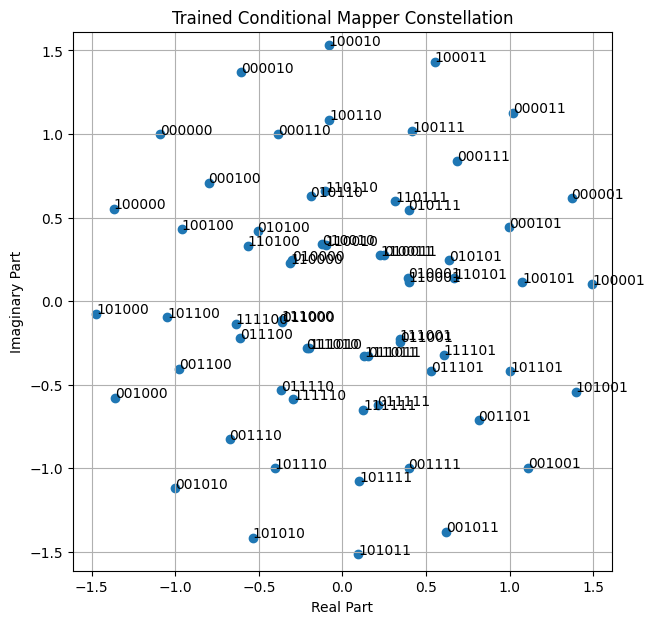

In [ ]:
def load_weights(model, model_weights_path):
    model(1, tf.constant(10.0, tf.float32))
    with open(model_weights_path, 'rb') as f:
        weights = pickle.load(f)
    model.set_weights(weights)
    
# Load the model and weights
model = E2ESystem('neural-receiver', training=True, use_fec=True)
load_weights(model, "10000_resNF_pilot1_neural_receiver_model_weights.pkl")

# Get constellation points from mapper
c = binary_source([batch_size, 1, 1, n])
_, constellation_points = model._mapper(c, ebno_db, training=False)
constellation_points = constellation_points.numpy()  # Take first batch sample

# Plot
figsize = (7, 7)
maxval = np.max(np.abs(constellation_points)) * 1.05
fig = plt.figure(figsize=figsize)
ax = fig.add_subplot(111)
plt.xlim(-maxval, maxval)
plt.ylim(-maxval, maxval)
plt.scatter(np.real(constellation_points), np.imag(constellation_points))
ax.set_aspect("equal", adjustable="box")
plt.grid(True, which="both", axis="both")
plt.title("Trained Conditional Mapper Constellation")
plt.xlabel("Real Part")
plt.ylabel("Imaginary Part")
for j, p in enumerate(constellation_points):
    plt.annotate(
        np.binary_repr(j, num_bits_per_symbol),
        (np.real(p), np.imag(p))
    )
plt.show()

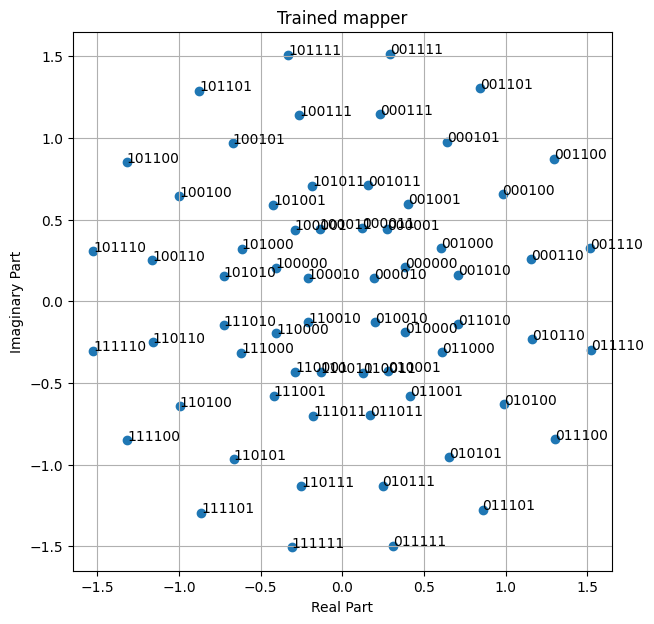

In [26]:
def load_weights(model, model_weights_path):
    model(1, tf.constant(10.0, tf.float32))
    with open(model_weights_path, 'rb') as f:
        weights = pickle.load(f)
    model.set_weights(weights)
    
# Load the model and weights
model = E2ESystem('neural-receiver', training=True, use_fec=True)
load_weights(model, "nf_neural_receiver_model_weights.pkl")

constellation_points = tf.complex(model.points_r, model.points_i).numpy()

figsize = (7, 7)
maxval = np.max(np.abs(constellation_points)) * 1.05

fig = plt.figure(figsize=figsize)
ax = fig.add_subplot(111)
plt.xlim(-maxval, maxval)
plt.ylim(-maxval, maxval)
plt.scatter(np.real(constellation_points), np.imag(constellation_points))
ax.set_aspect("equal", adjustable="box")
plt.grid(True, which="both", axis="both")
plt.title("Trained mapper")
plt.xlabel("Real Part")
plt.ylabel("Imaginary Part")

for j, p in enumerate(constellation_points):
    plt.annotate(
        np.binary_repr(j, num_bits_per_symbol),
        (np.real(p), np.imag(p))
    )

plt.show()

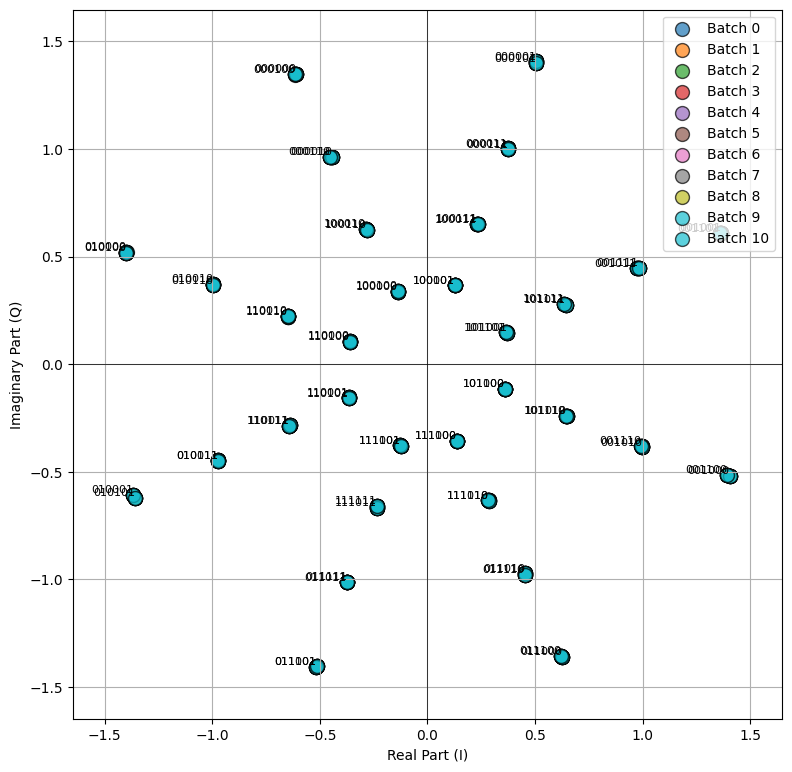

In [35]:
def plot_multi_batch_constellations(model, c, num_batches_to_plot=4, num_bits_per_symbol=6):
    # Get constellation points for all batches
    _, constellation_points = model._mapper(c, ebno_db, training=False)
    constellation_points = constellation_points.numpy()  # [batch, 16]
    
    # Limit to num_batches_to_plot
    num_batches = min(num_batches_to_plot, constellation_points.shape[0])
    
    # Setup plot
    figsize = (8, 8)
    maxval = np.max(np.abs(constellation_points[num_batches:])) * 1.1
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(-maxval, maxval)
    ax.set_ylim(-maxval, maxval)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, which="both", axis="both")
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.axvline(x=0, color='k', linewidth=0.5)
    
    # Color map for different batches
    colors = plt.cm.tab10(np.linspace(0, 1, num_batches))
    
    # Plot each batch's constellation
    for batch_idx in range(num_batches):
        points = constellation_points[batch_idx]
        real_parts = np.real(points)
        imag_parts = np.imag(points)
        
        # Scatter plot for this batch
        ax.scatter(real_parts, imag_parts, 
                  c=[colors[batch_idx]], 
                  s=100,
                  alpha=0.7,
                  label=f'Batch {batch_idx}',
                  edgecolors='black',
                  linewidths=1)
        
        # Annotate with binary labels (only for first batch to avoid clutter)
        if batch_idx == 0:
            for j, p in enumerate(points):
                ax.annotate(
                    np.binary_repr(j, num_bits_per_symbol),
                    (np.real(p), np.imag(p)),
                    fontsize=8,
                    ha='right',
                    va='bottom'
                )
    
    ax.legend(loc='upper right')
    ax.set_xlabel("Real Part (I)")
    ax.set_ylabel("Imaginary Part (Q)")
    plt.tight_layout()
    plt.show()
    
    # for point_idx in range(2**num_bits_per_symbol):
    #     points_across_batches = constellation_points[:num_batches, point_idx]
    #     real_std = np.std(np.real(points_across_batches))
    #     imag_std = np.std(np.imag(points_across_batches))
        
    #     print(f"Point {np.binary_repr(point_idx, num_bits_per_symbol)}: "
    #           f"I_std={real_std:.4f}, Q_std={imag_std:.4f}")
    
    # # Overall variation metric
    # all_points = constellation_points[:num_batches].reshape(-1)
    # overall_std = np.std(all_points)
    # print(f"\nOverall constellation std: {overall_std:.4f}")
    # print(f"Max position difference: {np.max(np.abs(constellation_points[:num_batches] - constellation_points[0])):.4f}")

# Usage
load_weights(model, "30000_res_neural_receiver_model_weights.pkl")
plot_multi_batch_constellations(model, c, num_batches_to_plot=11, num_bits_per_symbol=6)

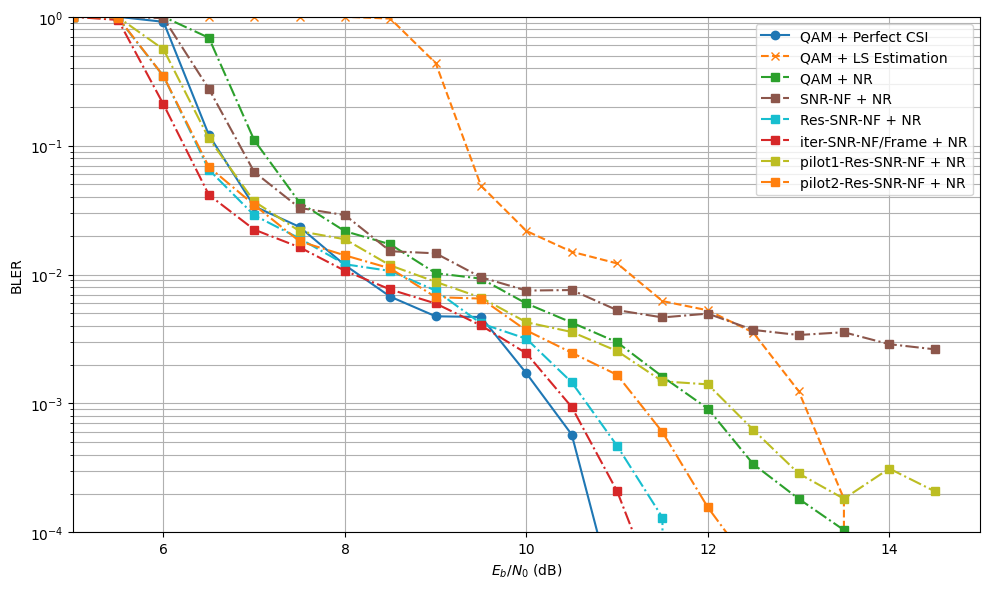

In [72]:
with open('E2E_baseline_result', 'rb') as file: 
        ebno_dbs, BLER_base, BER_base = pickle.load(file)
with open('10000_qam_neural_receiver_model_result', 'rb') as file: 
        ebno_dbs, BLER_qam, BER_qam = pickle.load(file)
with open('iter_neural_receiver_model_result', 'rb') as file: 
        ebno_dbs, BLER_nn, BER_nn = pickle.load(file)
with open('10000_neural_receiver_model_result', 'rb') as file: 
        ebno_dbs, BLER_nn2, BER_nn2 = pickle.load(file)
with open('10000_SNRNF_neural_receiver_model_result', 'rb') as file: 
        ebno_dbs, BLER_nf, BER_nf = pickle.load(file)
with open('10000_nf_neural_receiver_model_result', 'rb') as file: 
        ebno_dbs, BLER_nf3, BER_nf3 = pickle.load(file)

with open('10000_res_neural_receiver_model_result', 'rb') as file: 
        ebno_dbs, BLER_res, BER_res = pickle.load(file) # 30000 gives same performance
with open('10000_resNF_neural_receiver_model_result', 'rb') as file: 
        ebno_dbs, BLER_resnf, BER_resnf = pickle.load(file) # 30000 gives same performance
with open('10000_resNF_pilot1_neural_receiver_model_result', 'rb') as file: 
        ebno_dbs, BLER_pilot1, BER_pilot1 = pickle.load(file) # 30000 gives same performance
with open('10000_resNF_pilot2_neural_receiver_model_result', 'rb') as file: 
        ebno_dbs, BLER_pilot2, BER_pilot2 = pickle.load(file) # 30000 gives same performance

plt.figure(figsize=(10,6))
# Baseline
plt.semilogy(ebno_dbs, BLER_base['baseline-perfect-csi'], 'o-', c=f'C0', label=f'QAM + Perfect CSI')
plt.semilogy(ebno_dbs, BLER_base['baseline-ls-estimation'], 'x--', c=f'C1', label=f'QAM + LS Estimation')
plt.semilogy(ebno_dbs, BLER_qam['neural-receiver-standard'], 's-.', c=f'C2', label=f'QAM + NR')

# Neural receiver
# plt.semilogy(ebno_dbs, BLER_nf3['neural-receiver-standard'], 's-.', c=f'C6', label=f'No SNR-NF + NR')
plt.semilogy(ebno_dbs, BLER_nf['neural-receiver-standard'], 's-.', c=f'C5', label=f'SNR-NF + NR')
# plt.semilogy(ebno_dbs, BLER_nn2['neural-receiver-standard'], 's-.', c=f'C4', label=f'SNR-Frame + NR')

plt.semilogy(ebno_dbs, BLER_resnf['neural-receiver-standard'], 's-.', c=f'C9', label=f'Res-SNR-NF + NR')
# plt.semilogy(ebno_dbs, BLER_res['neural-receiver-standard'], 's-.', c=f'C8', label=f'Res-SNR-Frame + NR')

plt.semilogy(ebno_dbs, BLER_nn['neural-receiver-standard'], 's-.', c=f'C3', label=f'iter-SNR-NF/Frame + NR')

plt.semilogy(ebno_dbs, BLER_pilot1['neural-receiver-standard'], 's-.', c=f'C8', label=f'pilot1-Res-SNR-NF + NR')
plt.semilogy(ebno_dbs, BLER_pilot2['neural-receiver-standard'], 's-.', c=f'C11', label=f'pilot2-Res-SNR-NF + NR')

# I overwritten a result but SNR Non-frame with same long training approahces frame, so SNR is the real benefit


plt.xlabel(r"$E_b/N_0$ (dB)")
plt.ylabel("BLER")
plt.grid(which="both")
plt.ylim((1e-4, 1.0))
plt.xlim((5, 15))
plt.legend()
plt.tight_layout()

Finally, we plots the BLERs

In [256]:
with open('SISO_highco_coderate78', 'wb') as f:
    pickle.dump((ebno_dbs, BLER, BER), f)
with open('SISO_highco_uncoded', 'wb') as f:
    pickle.dump((ebno_dbs, BLER_uc, BER_uc), f)

In [257]:
with open('SISO_coderate78', 'rb') as file: 
        ebno_dbs, BLER_s, BER_s = pickle.load(file)
with open('SISO_uncoded', 'rb') as file: 
        ebno_dbs, BLER_uc_s, BER_uc_s = pickle.load(file)
# with open('SIMO_coderate78', 'rb') as file: 
#         ebno_dbs, BLER_m, BER_m = pickle.load(file)
# with open('SIMO_uncoded', 'rb') as file: 
#         ebno_dbs, BLER_uc_m, BER_uc_m = pickle.load(file)
with open('SISO_highco_coderate78', 'rb') as file: 
        ebno_dbs, BLER_c, BER_c = pickle.load(file)
with open('SISO_highco_uncoded', 'rb') as file: 
        ebno_dbs, BLER_uc_c, BER_uc_c = pickle.load(file)

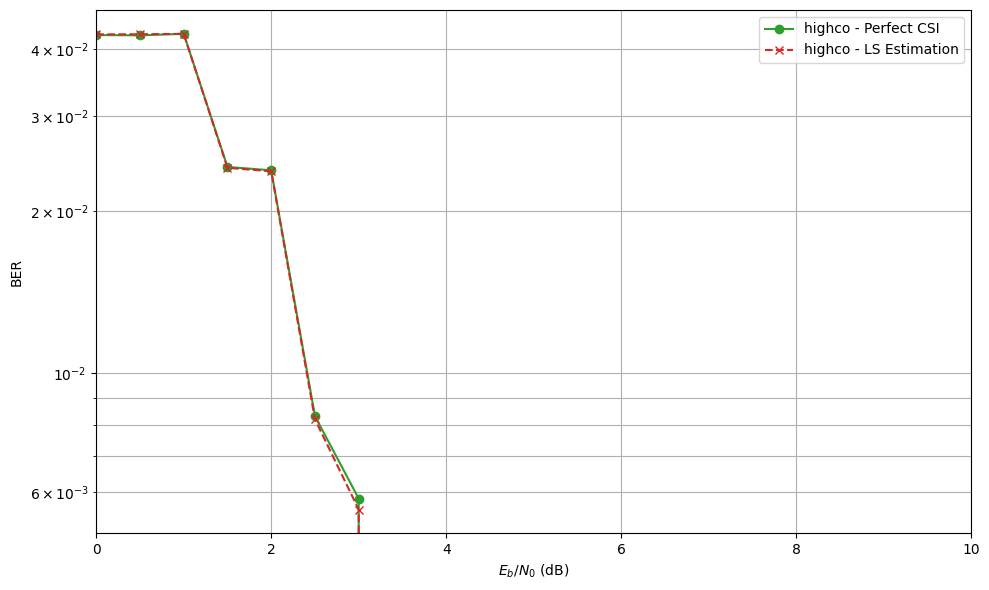

In [258]:
plt.figure(figsize=(10,6))
# Baseline - Perfect CSI
# plt.semilogy(ebno_dbs, BER_s['baseline-perfect-csi'], 'o-', c=f'C0', label=f'coderate78 - Perfect CSI')
# # Baseline - LS Estimation
# plt.semilogy(ebno_dbs, BER_s['baseline-ls-estimation'], 'x--', c=f'C1', label=f'coderate78 - LS Estimation')

# plt.semilogy(ebno_dbs, BER_uc_s['baseline-perfect-csi'], 'o-', c=f'C4', label=f'uncoded - Perfect CSI')
# plt.semilogy(ebno_dbs, BER_uc_s['baseline-ls-estimation'], 'x--', c=f'C5', label=f'uncoded - LS Estimation')

plt.semilogy(ebno_dbs, BER_c['baseline-perfect-csi'], 'o-', c=f'C2', label=f'highco - Perfect CSI')
plt.semilogy(ebno_dbs, BER_c['baseline-ls-estimation'], 'x--', c=f'C3', label=f'highco - LS Estimation')
# plt.semilogy(ebno_dbs, BER_uc_c['baseline-perfect-csi'], 'o-', c=f'C6', label=f'uncoded-highco - Perfect CSI')
# plt.semilogy(ebno_dbs, BER_uc_c['baseline-ls-estimation'], 'x--', c=f'C7', label=f'uncoded-highco - LS Estimation')

# Neural receiver
# plt.semilogy(ebno_dbs, BLER['neural-receiver'], 's-.', c=f'C2', label=f'Neural receiver')
#
plt.xlabel(r"$E_b/N_0$ (dB)")
plt.ylabel("BER")
plt.grid(which="both")
# plt.ylim((1e-5, 1.0))
plt.xlim((0, 10))
plt.legend()
plt.tight_layout()

## Pre-computed Results <a class="anchor" id="Pre-computed-Results"></a>

In [20]:
pre_computed_results = "{'baseline-perfect-csi': [1.0, 1.0, 1.0, 1.0, 1.0, 0.9916930379746836, 0.5367080479452054, 0.0285078125, 0.0017890625, 0.0006171875, 0.0002265625, 9.375e-05, 2.34375e-05, 7.8125e-06, 1.5625e-05, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 'baseline-ls-estimation': [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9998022151898734, 0.9199448529411764, 0.25374190938511326, 0.0110234375, 0.002078125, 0.0008359375, 0.0004375, 0.000171875, 9.375e-05, 4.6875e-05, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 'neural-receiver': [1.0, 1.0, 1.0, 1.0, 1.0, 0.9984177215189873, 0.7505952380952381, 0.10016025641025642, 0.00740625, 0.0021640625, 0.000984375, 0.0003671875, 0.000203125, 0.0001484375, 3.125e-05, 2.34375e-05, 7.8125e-06, 7.8125e-06, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]}"
BLER = eval(pre_computed_results)

## References <a class="anchor" id="References"></a>

[1] M. Honkala, D. Korpi and J. M. J. Huttunen, "DeepRx: Fully Convolutional Deep Learning Receiver," in IEEE Transactions on Wireless Communications, vol. 20, no. 6, pp. 3925-3940, June 2021, doi: 10.1109/TWC.2021.3054520.

[2] F. Ait Aoudia and J. Hoydis, "End-to-end Learning for OFDM: From Neural Receivers to Pilotless Communication," in IEEE Transactions on Wireless Communications, doi: 10.1109/TWC.2021.3101364.

[3] Kaiming He, Xiangyu Zhang, Shaoqing Ren, Jian Sun, "Deep Residual Learning for Image Recognition", Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition (CVPR), 2016, pp. 770-778

[4] G. Böcherer, "Achievable Rates for Probabilistic Shaping", arXiv:1707.01134, 2017.